In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from skimage import io 
from scipy.ndimage import gaussian_filter
from skimage.feature import blob_dog, blob_log
from skimage.feature import peak_local_max
import os
from misc import show_imset_with_idx
from scipy.ndimage import center_of_mass

In [2]:
# sparse data
im_folder = os.path.join(os.getcwd(), "data", "tank_sparse")

im_names = sorted(os.listdir(im_folder))
num_frames = len(im_names)
print(f'the # of frames: {num_frames}')


the # of frames: 2


# test 
step-by-step PSF cropping procedures

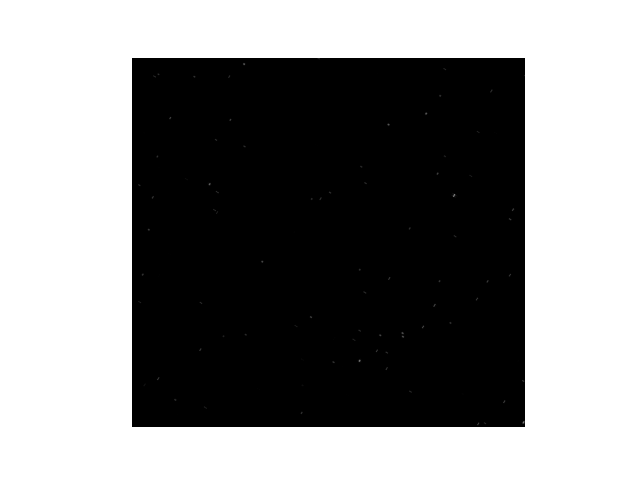

In [3]:
# read exp images
frame_idx = 0 
img = io.imread(os.path.join(im_folder, im_names[frame_idx]))
img = img[200:-200, 200:-200]  # crop a bit to avoid edge effects
# img = img[1350:-500, 1200:-760]  # crop a bit to avoid edge effects
img01 = (img-img.min())/(img.max()-img.min())  # 01 normalized images

plt.close()
plt.figure()
plt.imshow(img01, cmap='gray')
plt.axis('off')
plt.show()

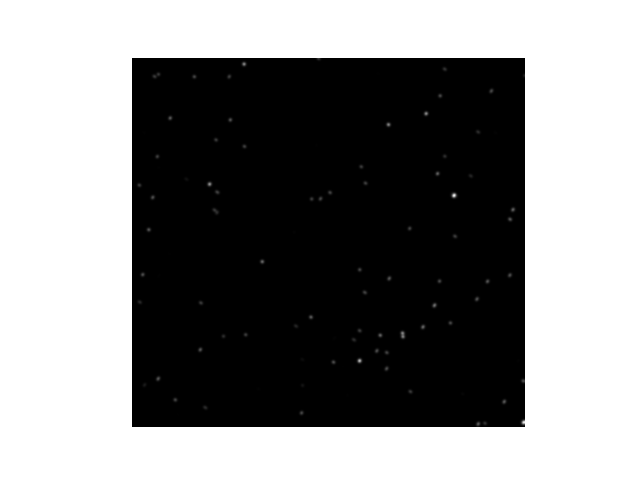

In [4]:
# from psfs to blobs
blur_sigma = 5
img_blobs = gaussian_filter(img01, sigma=blur_sigma)
img_blobs = (img_blobs-img_blobs.min())/(img_blobs.max()-img_blobs.min())

plt.close()
plt.figure()
plt.imshow(img_blobs, cmap='gray')
plt.axis('off')
# plt.colorbar()
plt.show()

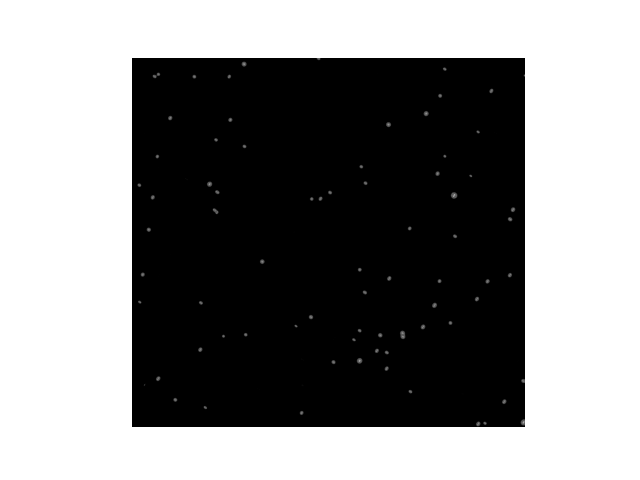

In [5]:
# binarization
# binary_threshold = 0.2  # binarization threshold
binary_threshold = 0.1  # binarization threshold
img_blobs_binary = (img_blobs>binary_threshold).astype(np.float32)

plt.close()
plt.figure()
plt.imshow(img_blobs_binary+img01*2, cmap='gray')

plt.axis('off')
plt.show()

the # of detected blobs: 76


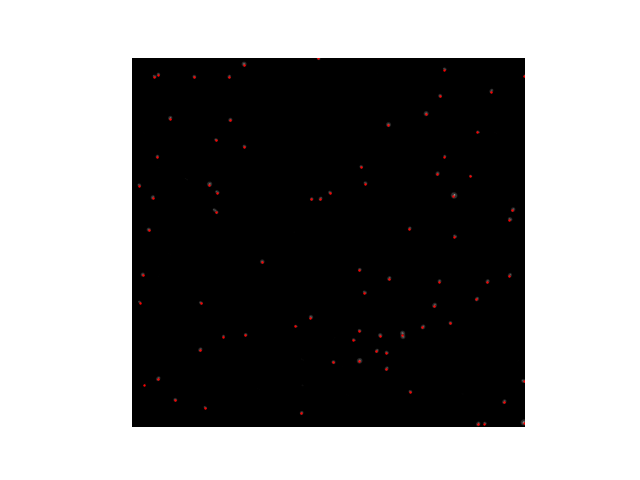

In [6]:
# blob detection
# max_sigma: maximum standard deviation of blobs to be detected
# threshold: local maxima smaller than threshold are ignored
blob_max_sigma = 10
blob_threshold = 0.5
blobs_ = blob_log(img_blobs_binary, max_sigma=blob_max_sigma, threshold=blob_threshold)  
# blobs_rc = blob_dog(img_blobs_binary, max_sigma=15, threshold=.4)
blobs_ = np.array(blobs_[:, :2])  # take x/column and y/row indices of detected blobs
print(f'the # of detected blobs: {len(blobs_)}')

plt.close()
plt.figure()
plt.imshow(img_blobs_binary+img01*5, cmap='gray')
plt.scatter(blobs_[:, 1], blobs_[:, 0], marker='.', c='r', s=2)
# plt.scatter(blobs_[:, 1], blobs_[:, 0], marker='.', c='r', s=20)
plt.axis('off')
plt.show()


In [7]:
psf_collection_ = []
w05 = 10  # half size of the cropping square
dh_flag = False  # if it is double helix, two-blob feature will be used for filtering

# exclude marginal PSFs
blobs = blobs_.copy()
non_edge = (blobs[:, 0]>w05) & (blobs[:, 0]<(img.shape[0]-w05)) & (blobs[:, 1]>w05) & (blobs[:, 1]<(img.shape[1]-w05))
blobs = blobs[non_edge, :]

# exclude overlapping and refine the corpping, specificly for double helix
w05_ = w05  # half size of the refined cropping
rc0 = np.array([w05, w05]) # cropping center
blob_rcs = []
for rc in blobs:
    r, c = int(rc[0]), int(rc[1])
    psf = img[r-w05: r+w05+1, c-w05: c+w05+1]
    
    if dh_flag:
        # psf filtering by two-peak feature of double helix psf
        peaks = peak_local_max(psf, min_distance=2, threshold_rel=0.2, exclude_border=False)  # find maxima
        if peaks.shape[0]==2:  # if there are only two local maxima
            rc_ = rc+(np.mean(peaks, axis=0)-rc0) # update the crop center
            r, c = int(rc_[0]), int(rc_[1])
            psf = img[r-w05_:r+w05_+1, c-w05_:c+w05_+1]
            blob_rcs.append(rc_)
            psf_collection_.append(psf)
    else:
        # psf cropping refining by center of mass
        rr, cc = center_of_mass(psf)
        rc_ = rc+(np.array([rr, cc])-rc0)
        psf = img[r-w05_:r+w05_+1, c-w05_:c+w05_+1]
        blob_rcs.append(rc_)
        psf_collection_.append(psf)
    
    

    
psf_collection_ = np.array(psf_collection_)
blob_rcs = np.array(blob_rcs)

print(f'the # of remaining blobs and cropped PSFs: {len(blob_rcs)}')

the # of remaining blobs and cropped PSFs: 72


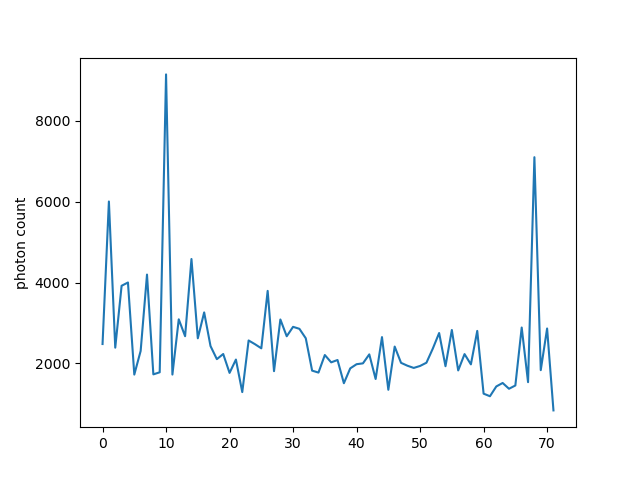

In [8]:
photons = np.sum(psf_collection_, axis=(1, 2))

plt.figure()
plt.plot(photons)
plt.ylabel('photon count')
plt.show()

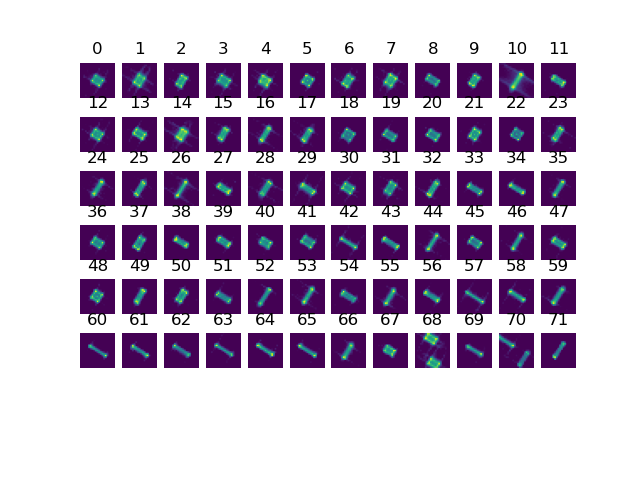

In [9]:
# photon thresholding
photon_threshold = 500
psf_collection = psf_collection_.copy()
psf_collection = psf_collection[photons>photon_threshold]
# print(f'the # of remained PSFs after photon thresholding: {psf_collection.shape[0]}')
show_imset_with_idx(psf_collection, rc=(len(psf_collection)//12+1, 12))

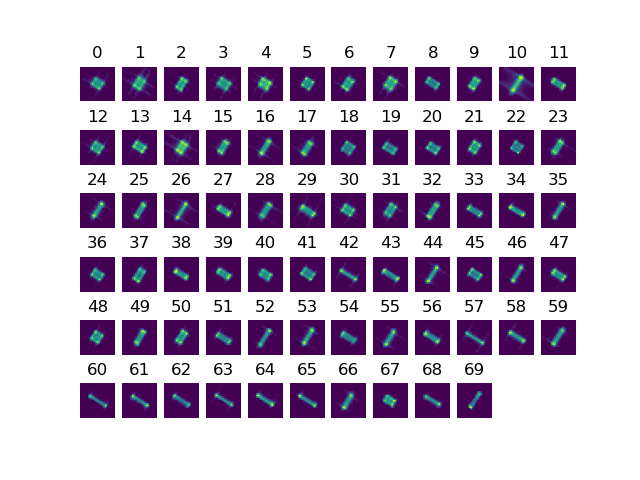

In [10]:
# manually fitlering
ids_delete = [68, 70]
blob_rcs = np.delete(blob_rcs, ids_delete, axis=0)
psf_collection = np.delete(psf_collection, ids_delete, axis=0)
# print(f'the number of remained cropped PSFs: {len(psf_collection)}')
plt.close()
show_imset_with_idx(psf_collection, rc=(len(psf_collection)//12+1, 12))

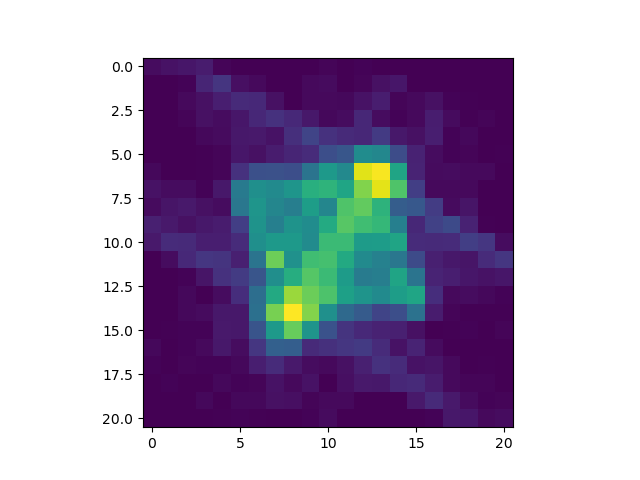

In [11]:
# maximum projection
plt.close()
plt.figure()
plt.imshow(np.max(psf_collection, axis=0))
plt.show()

# PSF collection

In [12]:
# this function assembles the all the procedures above

def collect_PSFs(img, blur_sigma, binary_threshold, blob_max_sigma, blob_threshold, w05, dh_flag, photon_threshold):
    img01 = (img-img.min())/(img.max()-img.min())  # 01 normalized images
    # blur_sigma = 5
    img_blobs = gaussian_filter(img01, sigma=blur_sigma)
    img_blobs = (img_blobs-img_blobs.min())/(img_blobs.max()-img_blobs.min())
    # binary_threshold = 0.2  # binarization threshold
    img_blobs_binary = (img_blobs>binary_threshold).astype(np.float32)
    # blob_max_sigma = 10
    # blob_threshold = 0.5
    blobs_ = blob_log(img_blobs_binary, max_sigma=blob_max_sigma, threshold=blob_threshold)  
    # blobs_rc = blob_dog(img_blobs_binary, max_sigma=15, threshold=.4)
    blobs_ = np.array(blobs_[:, :2])  # take x/column and y/row indices of detected blobs
    psf_collection_ = []
    # w05 = 12  # half size of the cropping square

    # exclude marginal PSFs
    blobs = blobs_.copy()
    non_edge = (blobs[:, 0]>w05) & (blobs[:, 0]<(img.shape[0]-w05)) & (blobs[:, 1]>w05) & (blobs[:, 1]<(img.shape[1]-w05))
    blobs = blobs[non_edge, :]

    # exclude overlapping and refine the corpping, specificly for double helix
    w05_ = w05  # half size of the refined cropping
    rc0 = np.array([w05, w05]) # cropping center
    blob_rcs = []
    
    for rc in blobs:
        r, c = int(rc[0]), int(rc[1])
        psf = img[r-w05: r+w05+1, c-w05: c+w05+1]
        if dh_flag:
            # psf filtering by two-peak feature of double helix psf
            peaks = peak_local_max(psf, min_distance=2, threshold_rel=0.2, exclude_border=False)  # find maxima
            if peaks.shape[0]==2:  # if there are only two local maxima
                rc_ = rc+(np.mean(peaks, axis=0)-rc0) # update the crop center
                r, c = int(rc_[0]), int(rc_[1])
                psf = img[r-w05_:r+w05_+1, c-w05_:c+w05_+1]
                blob_rcs.append(rc_)
                psf_collection_.append(psf)
        else:
            # psf cropping refining by center of mass
            rr, cc = center_of_mass(psf)
            rc_ = rc+(np.array([rr, cc])-rc0)
            psf = img[r-w05_:r+w05_+1, c-w05_:c+w05_+1]
            blob_rcs.append(rc_)
            psf_collection_.append(psf)
            
    psf_collection_ = np.array(psf_collection_)
    blob_rcs = np.array(blob_rcs)
    photons = np.sum(psf_collection_, axis=(1, 2))
    # photon_threshold = 1000
    psf_collection = psf_collection_.copy()
    psf_collection = psf_collection[photons>photon_threshold]
    
    return psf_collection



In [13]:
# define frame indices
frame_step_size = 1  # TP
# frame_step_size = 1100  # DH
frame_ids = np.arange(0, num_frames, frame_step_size)
print(frame_ids)

[0 1]


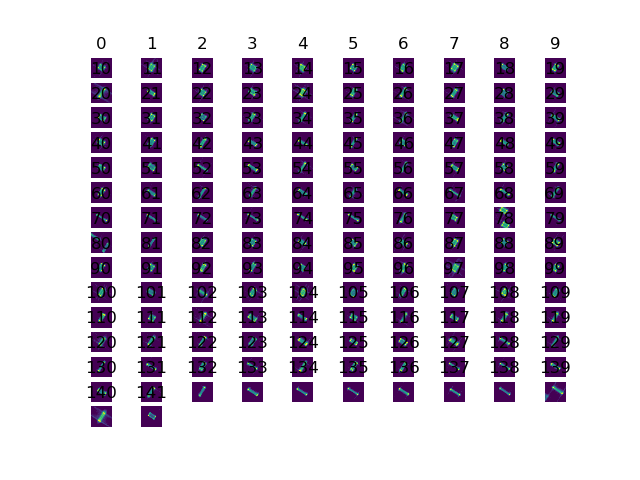

In [14]:
psf_measurement = []
for idx in frame_ids:
    img = io.imread(os.path.join(im_folder, im_names[idx]))[200:-200, 200:-200]
    psfs = collect_PSFs(img, blur_sigma, binary_threshold, blob_max_sigma, blob_threshold, w05, dh_flag, photon_threshold)
    psf_measurement.append(psfs)
    
psf_measurement = np.concatenate(psf_measurement, axis=0)

show_imset_with_idx(psf_measurement, rc=(len(psf_measurement)//10+1, 10))  

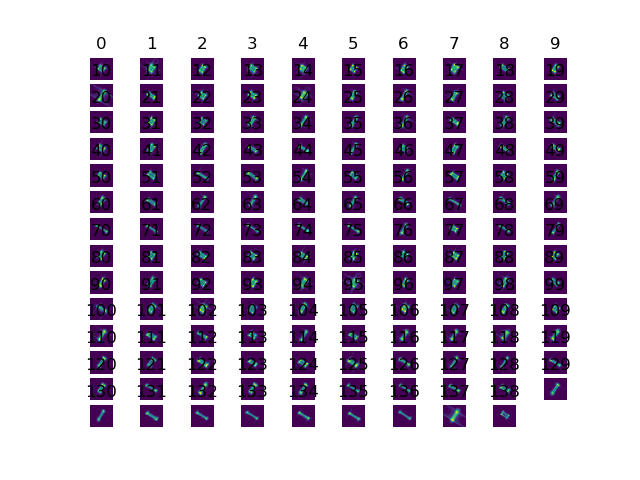

In [15]:
ids_delete = [68, 70, 139]  
psf_measurement = np.delete(psf_measurement, ids_delete, axis=0)
plt.close()
show_imset_with_idx(psf_measurement, rc=(len(psf_measurement)//10+1, 10))

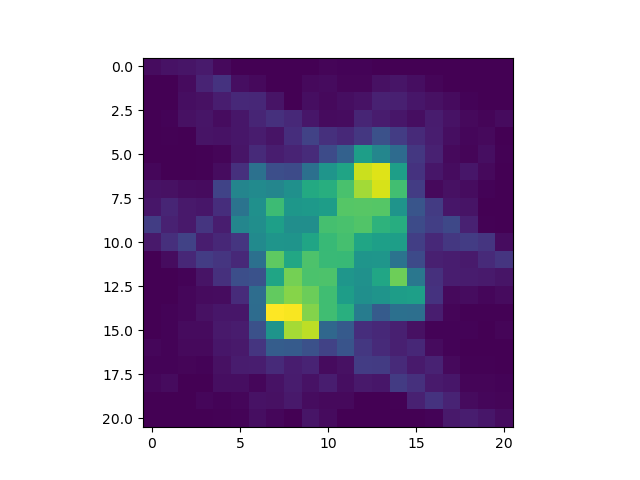

In [16]:
# maximum projection of all the collected PSFs
plt.close()
plt.figure()
plt.imshow(np.max(psf_measurement, axis=0))
plt.show()

In [17]:
# save the psf collection
# np.save('tp_psf_collection_0101.npy', psf_measurement)
# np.save('dh_psf_collection_0102.npy', psf_measurement)
# np.save('psf_collection_tp18.npy', psf_measurement)